In [2]:
# =============================================================================
# 1. ENVIRONMENT SETUP & MODULE IMPORTS
# =============================================================================
"""
Initialize the analysis environment by loading essential modules and setting up
the Python path to access custom analysis functions.
"""

# Enable automatic reloading of modules for interactive development
%load_ext autoreload
%autoreload 2

# Import essential system modules
import sys
from pathlib import Path

# Define the path to custom analysis modules
# Note: Update this path to match your local installation
MODULE_PATH = Path("/root/capsule/src/aind_dft_ephys_analysis")

# Add module path to system path for importing custom functions
if str(MODULE_PATH) not in sys.path:
    sys.path.insert(0, str(MODULE_PATH))

print(f"✅ Analysis modules loaded from: {MODULE_PATH}")
print("🔄 Auto-reload enabled for interactive development")

✅ Analysis modules loaded from: /root/capsule/src/aind_dft_ephys_analysis
🔄 Auto-reload enabled for interactive development


In [41]:
import cloudpickle
from pathlib import Path

# Path to the cloudpickle file
file_path = Path("/root/capsule/scratch/model_comparison/753125_2024-10-10_14-41-23/"
                 "QLearning_L1F1_softmax/fitted_agent.cloudpickle")

# Load the object/root/capsule/scratch/model_comparison/753125_2024-10-10_14-41-23/QLearning_L1F1_softmax
with file_path.open("rb") as f:
    fitted_agent = cloudpickle.load(f)

# Inspect the loaded object
print(type(fitted_agent))
print(fitted_agent)  # or use more specific attributes depending on the object

<class 'aind_dynamic_foraging_models.generative_model.forager_q_learning.ForagerQLearning'>


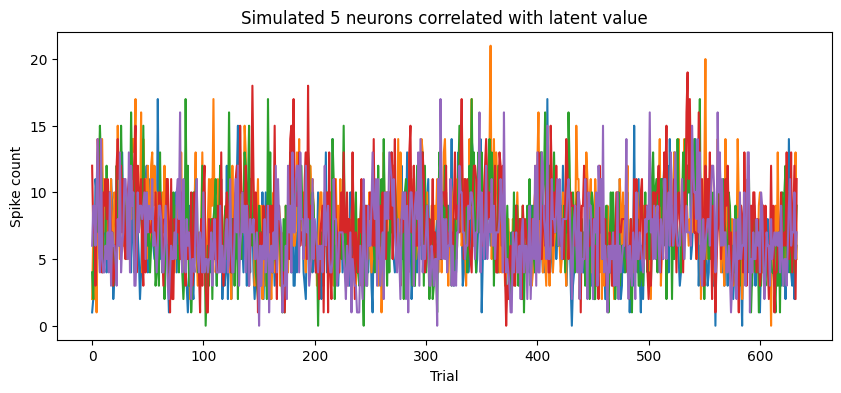

Simulated spikes shape: (634, 50)


In [5]:

from simulate_neural_activities import simulate_neurons

session_name = "753125_2024-10-10_14-41-23"
parent_folder = "/root/capsule/scratch/model_comparison/"
behavior_model_path = "ForagingCompareThreshold_L1_CKnone_ResetT_StayBiasF_FixThrF/fitted_agent.cloudpickle"

simulate_params = {
    "n_neurons": 50,
    "rho_mean": 0.6,
    "rho_std": 0.1,
    "baseline_range": (2, 5),
    "gain_range": (5, 15)
}

simulated_spikes,latent_trimmed = simulate_neurons(
    session_name,
    parent_folder,
    behavior_model_path,
    simulate_method="poisson",
    simulate_params=simulate_params,
    plot_example=True
)

print("Simulated spikes shape:", simulated_spikes.shape)

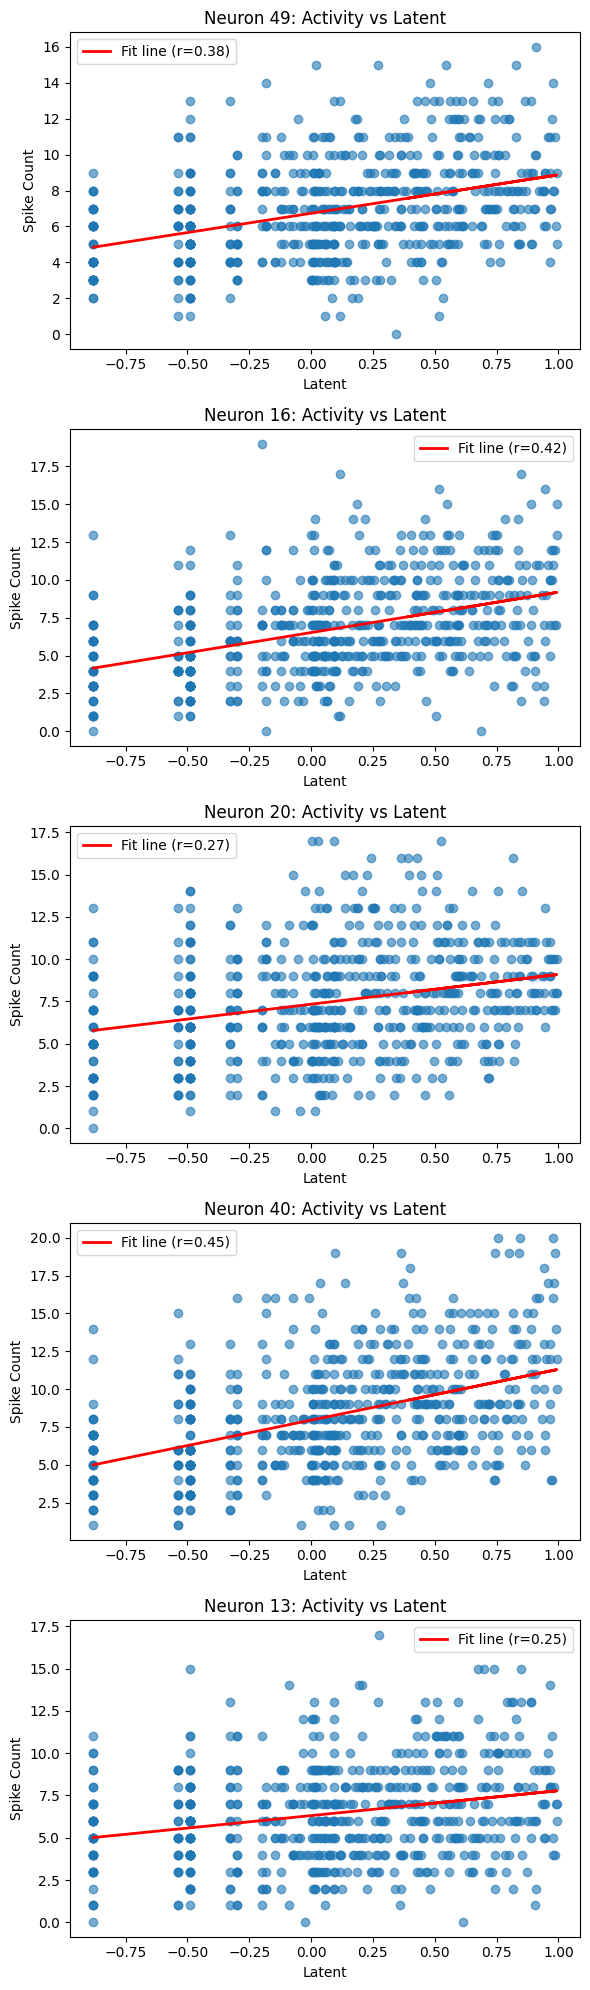

Pearson correlations: None


In [22]:
# Assuming you already have:
# simulated_spikes, latent_trimmed = simulate_neurons(...)
from simulate_neural_activities import plot_activity_vs_latent
import numpy as np

correlations = plot_activity_vs_latent(simulated_spikes, latent_trimmed, n_neurons=5)
print("Pearson correlations:", correlations)

   Neuron     Slope  Correlation  Latent
0       0 -2.656719    -0.269866  deltaQ
1       1 -3.367592    -0.313797  deltaQ
2       2 -4.948394    -0.440210  deltaQ
3       3 -4.046696    -0.366531  deltaQ
4       4 -3.385709    -0.322076  deltaQ


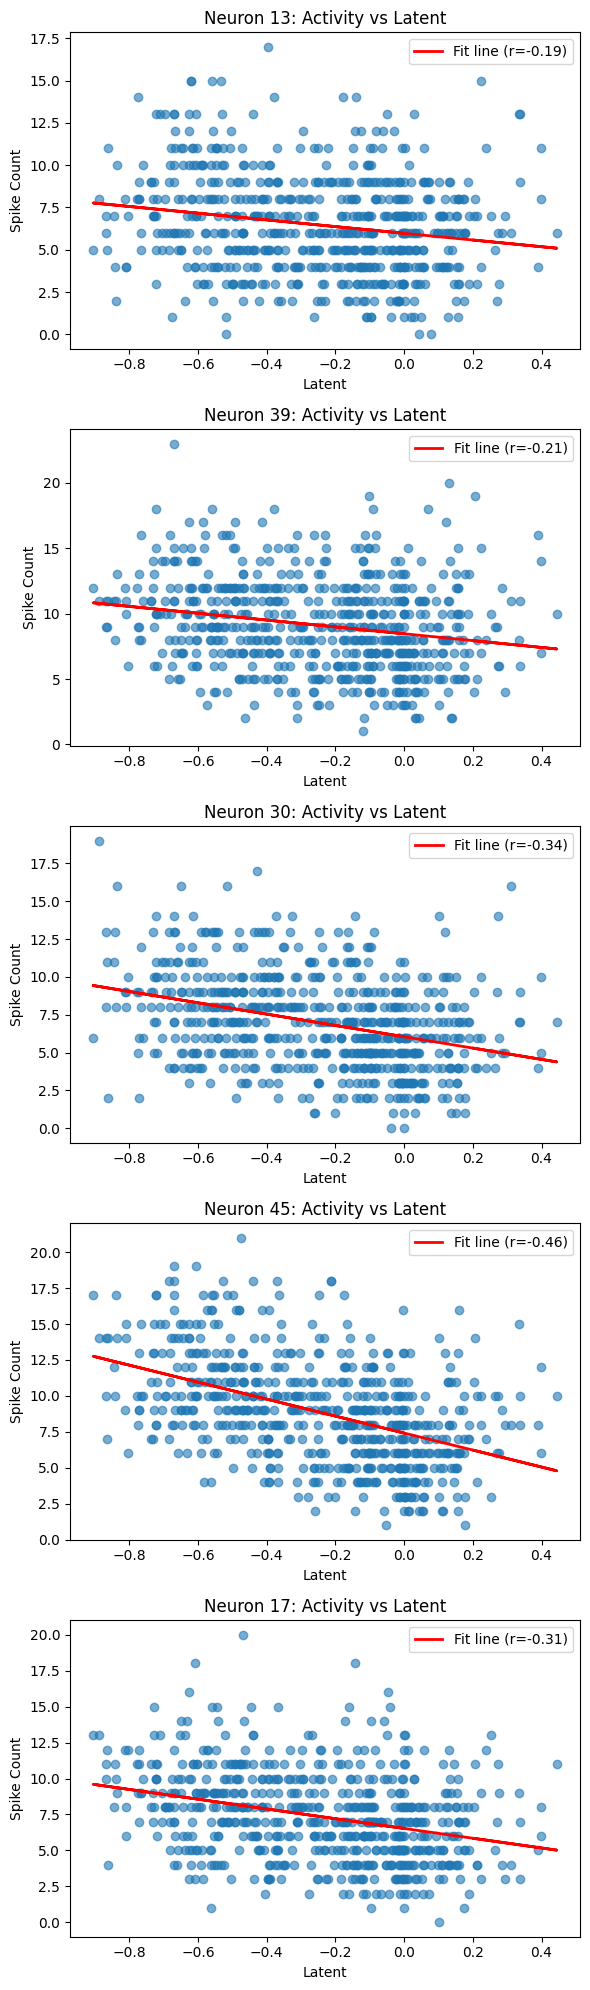

In [7]:
# simulated_spikes from previous simulation
from simulate_neural_activities import fit_activity_to_latent_complete, plot_activity_vs_latent

session_name = "753125_2024-10-10_14-41-23"
parent_folder = "/root/capsule/scratch/model_comparison/"
new_behavior_model_path = "QLearning_L1F1_softmax/fitted_agent.cloudpickle"

results_df, latent_values = fit_activity_to_latent_complete(
    simulated_spikes,
    session_name,
    parent_folder,
    new_behavior_model_path,
    latent="deltaQ"
)

print(results_df.head())

plot_activity_vs_latent(simulated_spikes, latent_values, n_neurons=5)
# Optionally save to CSV
#results_df.to_csv("simulated_spikes_correlation_results.csv", index=False)

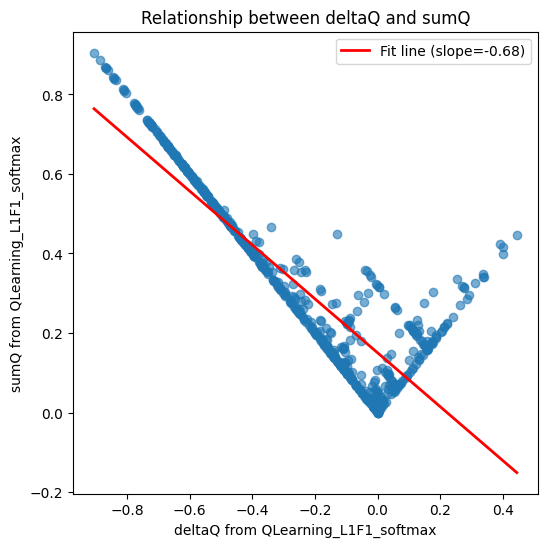

In [9]:
from simulate_neural_activities import plot_latent_relationship

parent_folder = "/root/capsule/scratch/model_comparison/"
session_name = "753125_2024-10-10_14-41-23"
models = [
    "ForagingCompareThreshold_L1_CKnone_ResetT_StayBiasF_FixThrF",
    "QLearning_L1F1_softmax"
]


models = [
    "QLearning_L1F1_softmax",
    "QLearning_L1F1_softmax"
]

latents = ["deltaQ", "sumQ"]

latent1, latent2 = plot_latent_relationship(parent_folder, session_name, models, latents)